<a href="https://colab.research.google.com/github/schere3/app1/blob/main/Rodriguez_Scherezade_Tarea1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1: Análisis Exploratorio de Datos (EDA)

**Objetivo:** Aplicar técnicas de exploración, limpieza y descripción estadística sobre un nuevo conjunto de datos.

**Instrucciones:**
1. Carga el dataset de los pasajeros del [Titanic](https://www.kaggle.com/competitions/titanic/data?select=train.csv).
2. Realiza una inspección inicial para entender la estructura de los datos.
3. Detecta y maneja datos faltantes y duplicados.
4. Extrae estadísticas descriptivas clave.
5. Escribe tus conclusiones sobre la calidad y contenido de los datos.

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual opcional
sns.set_style("whitegrid")

### 1. Carga de Datos
Carga el archivo CSV en un DataFrame de Pandas llamado `df`.
Muestra las primeras 5 filas y 5 filas aleatorias para verificar que se cargó correctamente.

In [ ]:
df = pd.read_csv('train.csv')
df      # Mostramos los datos del dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.head(5)     # Muestra las 5 primeras filas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.sample(5)         # Muestra 5 filas aleatorias

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
188,189,0,3,"Bourke, Mr. John",male,40.0,1,1,364849,15.5000,NaN,Q
193,194,1,2,"Navratil, Master. Michel M",male,3.0,1,1,230080,26.0000,F2,S
552,553,0,3,"O'Brien, Mr. Timothy",male,NaN,0,0,330979,7.8292,NaN,Q
102,103,0,1,"White, Mr. Richard Frasar",male,21.0,0,1,35281,77.2875,D26,S
248,249,1,1,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,52.5542,D35,S


### 2. Inspección General
Responde a las siguientes preguntas mediante código:
* ¿Cuántas filas y columnas tiene el dataset? (`shape`)
* ¿Cuáles son los nombres de las columnas? (`columns`)
* ¿Qué tipos de datos (Dtype) tiene cada columna? (`info`)

In [ ]:
print(f"El tamaño del dataset es: {df.shape}")
print(f"Tenemos {df.shape[0]} filas y {df.shape[1]} columnas.")

El tamaño del dataset es: (891, 12)
Tenemos 891 filas y 12 columnas.


Los nombres de las columnas, es decir, las variables son:

In [ ]:
print(list(df.columns))

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Los datos de cada columna del dataset son del tipo (int, float, object), en efecto:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 2.1. Diccionario de Datos (Variables)
Analicemos las variables a tratar:
* **Variables Categóricas (Cualitativas):**
    * `survival`: Indica la supervivencia del pasajero (0: No, 1:Sí)
    * `pclass`: Representa la clase del billete (1: Primera, 2: Segunda, 3: Tercera).
    * `sex`: Indica el sexo del pasajero.
    * `embarked`: Representa el puerto de embarque del pasajero (C: Cherbourg, Q: Queenstown, S: Southampton).
    * `ticket`: Se refiere al número de billete.
    * `cabin`: Indica el número de camarote

* **Variables Numéricas (Cuantitativas):**
    * `age`: Representa la edad en años del pasajero.
    * `sibsp`:  Indica el número de hermanos o cónyuges a bordo del Titanic.
    * `parch`: Indica el número de padres o hijos a bordo del Titanic.
    * `fare`:  Representa la tarifa o precio del billete pagado por el pasajero.
   

- **Peculiaridades y Reglas de Registro**:
El dataset presenta matices técnicos que deben considerarse durante la fase de limpieza y procesamiento:

  * ` Precisión de la Edad (Age)`: Se registra de forma fraccionaria si el pasajero tenía menos de un año. Además, si la edad no pudo ser confirmada y fue estimada, se utiliza el formato xx.5


  **Definición de Relaciones Familiares**

  El dataset utiliza reglas estrictas para definir quiénes cuentan como familia a bordo, lo cual es vital para entender las redes de apoyo durante el naufragio:

   * `sibsp (Hermanos / Cónyuges)`: Incluye hermanos, hermanas, hermanastros y hermanastras. En cuanto a parejas, solo contabiliza a esposos y esposas, especificando que se ignoraron a amantes y prometidos.

   * `parch (Padres / Hijos)`: Incluye relaciones biológicas y legales como madre, padre, hijos e hijastros. Una distinción importante es que si un niño viajaba únicamente con una niñera, su valor de parch es 0, ya que la variable se limita a relaciones parentales directas.

### 3. Calidad de los Datos
Antes de analizar estadísticas, debemos depurar y limpiar los datos:
1.  **Duplicados:** Verifica si hay filas duplicadas y elimínalas si existen.


In [ ]:
df.duplicated().any()    # Verificamos si existen filas duplicadas

np.False_

Al no existir filas duplicadas, no se elimina ninguna.

2.  **Valores Nulos:** Muestra cuántos valores nulos (NaN) hay por columna.
    * *Reto:* Si encuentras nulos en variables numéricas, rellénalos con la **Mediana** (como vimos en clase para evitar sesgos por outliers).

In [ ]:
# 2 Muestra la cantidad de nulos por columna
df.isna().sum()     # isna() funcion que detecta vacios

# Una alternativa manual es usar info():
# Tamaño del dataset menos "non-null" equivale a los nulos de cada columna.
# Por último, sumar los nulos de cada columna

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# 3. Imputación (fillna) de nulos
# Anteriormente, hemos visto que la unica variable numerica que tiene no nulos es Age
df_completo = df.copy()

median_Age = df_completo['Age'].median()          # devuelve el valor 28.0
df_completo['Age'] = df_completo['Age'].fillna(median_Age)
df_completo

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Como la mayoría de los algoritmos de Machine Learning no funcionan correctamente si reciben valores NaN como entrada, es necesario tratarlos previamente.

 Tal como se solicitó en el reto, hemos completado los NaN mediante imputación estadística simple, reemplazando los valores faltantes con un valor central de la distribución; en nuestro caso, utilizamos la mediana.

A partir de ahora, procederemos a trabajar con df_copia.

### 4. Estadística Descriptiva
Utiliza la función `describe()` para obtener un resumen de las variables numéricas (media, desviación estándar, mínimos y máximos).

**Pregunta de análisis:** ¿Notas alguna columna con una desviación estándar (`std`) muy alta o valores máximos (`max`) extraños?

In [ ]:
# Trabajaremos sobre las variables cuantitativas
df_cuantitativo = df_completo[['Age','SibSp','Parch','Fare']]
df_cuantitativo.describe().T[['mean','std','min','max']]

,mean,std,min,max
Age,29.361582,13.019697,0.42,80.0000
SibSp,0.523008,1.102743,0.00,8.0000
Parch,0.381594,0.806057,0.00,6.0000
Fare,32.204208,49.693429,0.00,512.3292


La elevada desviación típica en la variable Fare evidencia una profunda brecha socioeconómica entre los pasajeros.

Estadísticamente, el valor máximo actúa como una anomalía (outlier), ya que se aleja drásticamente del comportamiento promedio, representando a un grupo selecto de la élite que viajaba en condiciones de lujo extremo.

### 5. Análisis de Variables Categóricas (Object)
Selecciona una columna de tipo texto (categórica) y cuenta cuántas veces aparece cada valor único (frecuencia).
*Pista: Usa `value_counts()`*

In [ ]:
# Seleccionamos la variable survived que representa la supervivencia del pasajero
df_categorica = df_completo['Survived']
df_categorica.value_counts()

,count
Survived,
0,549
1,342


### 6. Conclusiones del Análisis
Escribe aquí un breve párrafo resumiendo qué descubriste sobre el dataset:
* ¿Estaban los datos muy sucios?
* ¿Cuál es la variable con mayor dispersión?
* ¿Qué patrones iniciales observas?



   - El principal inconveniente reside en la falta de documentación sobre la edad y la asignación de camarotes. Esto resulta coherente dado el elevado número de víctimas y la pérdida de registros tras el trágico hundimiento del navío. Por lo demás, el conjunto de datos destaca por su limpieza, al no presentar registros duplicados.

   - La variable con mayor dispersión es fare, lo cual resulta una evidencia sobre la diferencia económica entre los pasajeros.

   - Se observa un sesgo de edad, situando al pasajero promedio entre los 28-30 años.

     La falta de información sobre la cabina es un indicador de que el pasajero probablemente pertenecía a las clases bajas o a la tripulación con menor rango. Por ello, existe una correlación directa entre los valores nulos y la clase social: mientras que la ubicación de los pasajeros de primera clase estaba  documentada, los registros de tercera clase eran escasos o desaparecieron en el naufragio.

# Parte 2. Ejercicios extras. (COMPLETAMENTE OPCIONAL, SOLO SE EVALUA LO ANTERIOR)

## Extra 1: Filtrado de Datos

Crea un nuevo DataFrame llamado `df_sobrevivientes` que contenga solo a los pasajeros que sobrevivieron (`Survived == 1`) y muestra cuántos son.

In [ ]:
df_sobrevivientes = df[df['Survived'] == 1]
df_sobrevivientes.shape

(342, 12)

## Extra 2: Agrupación

Calcula el precio promedio del ticket (`Fare`) por cada clase (`Pclass`). ¿Es la primera clase significativamente más cara?

In [ ]:
df.groupby('Pclass')['Fare'].mean()

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


Destacamos que el costo de un pasaje de primera clase es el triple que uno de segunda y, por ende, considerablemente más elevado que un ticket de tercera.

# Extra 3: Visualización Básica

Crea un histograma simple para ver la distribución de las edades de todos los pasajeros.

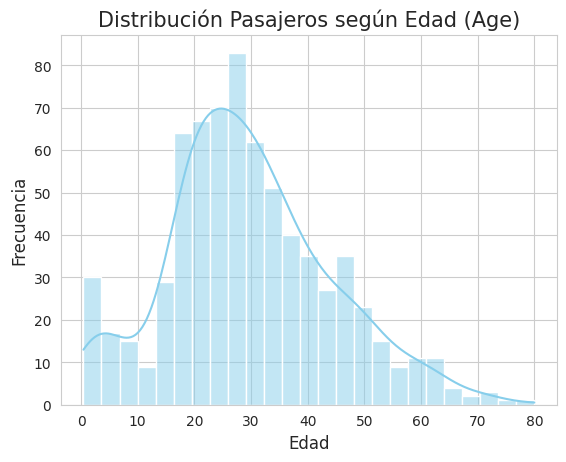

In [ ]:
sns.histplot(df['Age'], bins=25, color='skyblue', kde=True)       # Creamos el histograma

plt.title('Distribución Pasajeros según Edad (Age)', fontsize=15)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Extra 4: Creamos nuestra tabla cruzada

Utiliza `pd.crosstab` para ver la relación entre la Clase (`Pclass`) y si sobrevivió o no (`Survived`).

In [ ]:
pd.crosstab(df['Pclass'],df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


# Extra 5: Ingeniería de variables

Crea una nueva columna llamada `FamilySize` que sea la suma de `SibSp` (hermanos/esposos) y `Parch` (padres/hijos) + 1 (el pasajero mismo).

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


# Extra 6: Ordenamiento

Muestra los 5 pasajeros que pagaron la tarifa más alta (Fare), ordenando el DataFrame de forma descendente.

In [ ]:
df_desc = df.sort_values(by='Fare', ascending=False)
df_desc.head(5)               # Muestra las cinco primeras filas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,2
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,1
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,1
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,6
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,6
